# WISDM Human Activity Recognition

Import the libraries used in this notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

Set the data folder, the map from activity letter to name, and the lists of devices and sensors.

In [2]:
DATA_DIR = Path("data/wisdm-dataset")

RAW_DATA_DIR = DATA_DIR / "raw"

ACTIVITY_MAP = {
    "A": "walking",
    "B": "jogging",
    "C": "stairs",
    "D": "sitting",
    "E": "standing",
    "F": "typing",
    "G": "teeth",
    "H": "soup",
    "I": "chips",
    "J": "pasta",
    "K": "drinking",
    "L": "sandwich",
    "M": "kicking",
    "O": "catch",
    "P": "dribbling",
    "Q": "writing",
    "R": "clapping",
    "S": "folding",
}

ACTIVITIES = list(ACTIVITY_MAP.keys())

DEVICES = (
    "phone",
    "watch",
)
SENSORS = (
    "accel",
    "gyro",
)
COLUMNS = ["id", "activity", "timestamp", "x", "y", "z"]

Read all 204 raw files into one table `df`, removing the `;` at the end of each line.
The table is saved as a CSV cache, so the next run loads it much faster.

In [3]:
CACHE_PATH = Path("data/processed/all_data.csv")
RAW_DTYPES = {"id": "int16", "timestamp": "int64", "x": "float32", "y": "float32"}


def load_file_to_frame(file_path: Path, device: str, sensor: str) -> pd.DataFrame:
    df = pd.read_csv(
        file_path, header=None, names=COLUMNS, dtype={**RAW_DTYPES, "z": "str"}
    )
    df["z"] = df["z"].str.rstrip(";").astype("float32")  # drop the trailing ';' in bulk
    df["sensor"], df["device"] = sensor, device
    return df


def load_data() -> pd.DataFrame:
    frames = [
        load_file_to_frame(path, device, sensor)
        for device in DEVICES
        for sensor in SENSORS
        for path in sorted((RAW_DATA_DIR / device / sensor).glob("data_*.txt"))
    ]
    all_df = pd.concat(frames, ignore_index=True)  # one concat, not one per file
    all_df["activity_name"] = all_df["activity"].map(ACTIVITY_MAP)
    return all_df.astype(
        dict.fromkeys(["activity", "activity_name", "sensor", "device"], "category")
    )


CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

if CACHE_PATH.exists():
    df = pd.read_csv(CACHE_PATH, dtype={**RAW_DTYPES, "z": "float32"}).astype(
        dict.fromkeys(["activity", "activity_name", "sensor", "device"], "category")
    )
else:
    df = load_data()
    df.to_csv(CACHE_PATH, index=False)

Show the first 5 rows of the table.

In [4]:
df.head()

,id,activity,timestamp,x,y,z,sensor,device,activity_name
0,1600,A,252207666810782,-0.364761,8.793503,1.055084,accel,phone,walking
1,1600,A,252207717164786,-0.879730,9.768784,1.016998,accel,phone,walking
2,1600,A,252207767518790,2.001495,11.109070,2.619156,accel,phone,walking
3,1600,A,252207817872794,0.450623,12.651642,0.184555,accel,phone,walking
4,1600,A,252207868226798,-2.164352,13.928436,-4.422485,accel,phone,walking


Count how many subjects are in the data.

In [5]:
unique_subjects = df["id"].unique().tolist()

print(f"We have {len(unique_subjects)} subjects in the dataset")

We have 51 subjects in the dataset


Show the number of rows and columns.

In [6]:
df.shape

(15630426, 9)

Show summary numbers (mean, min, max, …) for the numeric columns.

In [7]:
df.describe()

,id,timestamp,x,y,z
count,1.563043e+07,1.563043e+07,1.563043e+07,1.563043e+07,1.563043e+07
mean,1.626267e+03,5.904473e+14,1.291597e-01,-1.607849e+00,5.570484e-01
std,1.478817e+01,6.034457e+14,4.792884e+00,5.025267e+00,3.970900e+00
min,1.600000e+03,2.681027e+11,-7.847761e+01,-7.847761e+01,-7.847761e+01
25%,1.614000e+03,1.079145e+14,-1.423934e+00,-4.157089e+00,-6.402740e-01
50%,1.627000e+03,3.704818e+14,-1.968384e-03,-1.290283e-01,4.527374e-03
75%,1.639000e+03,9.407683e+14,1.293311e+00,1.213215e-01,1.786685e+00
max,1.650000e+03,2.724599e+15,7.847761e+01,6.441166e+01,6.908195e+01


Plot how many rows each subject has for each activity.

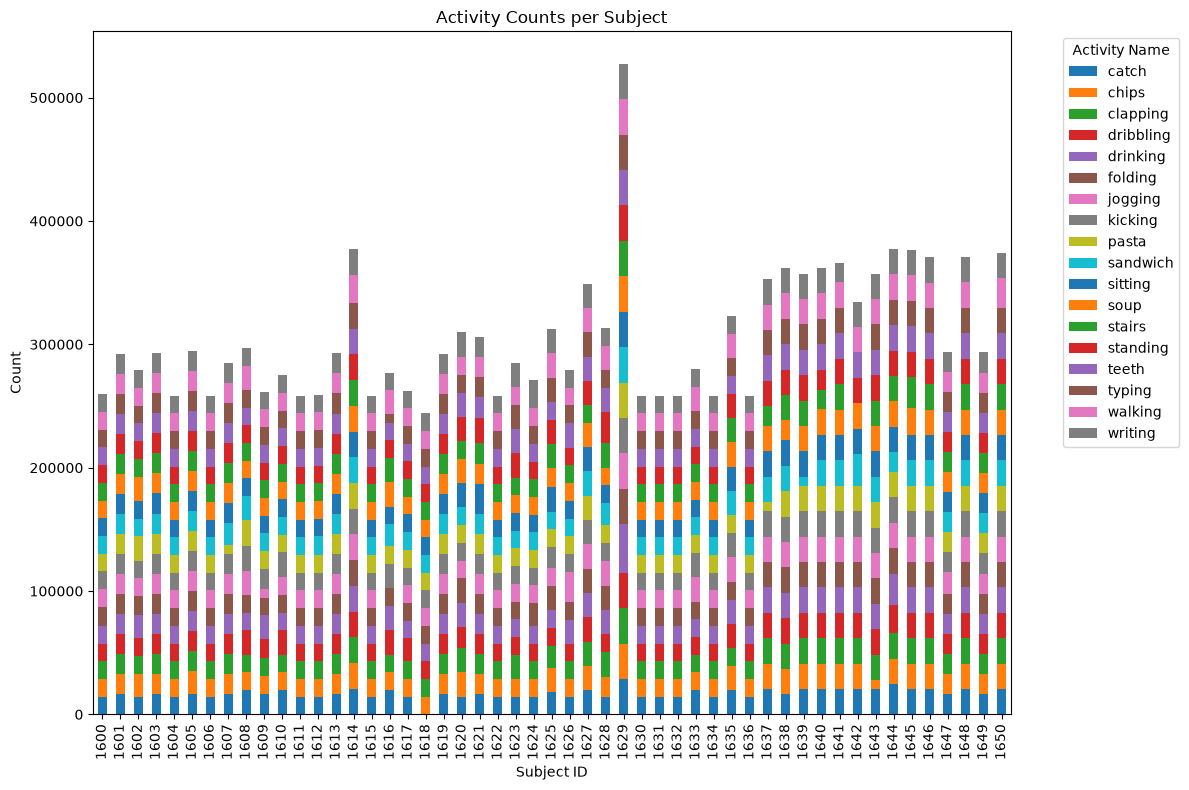

In [8]:
per_subject_activity_counts = (
    df.groupby(["id", "activity_name"], observed=True).size().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 8))
per_subject_activity_counts.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("Count")
ax.set_xlabel("Subject ID")
ax.set_title("Activity Counts per Subject")
ax.legend(title="Activity Name", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Sort the rows by time. Then give every continuous block of rows (same device, sensor, subject and activity) its own number, `run_id`.

In [9]:
df = df.sort_values(
    ["device", "sensor", "id", "timestamp"], kind="stable", ignore_index=True
)

key_cols = ["device", "sensor", "id", "activity"]
df["run_id"] = (
    df[key_cols].ne(df[key_cols].shift()).any(axis=1).cumsum().astype("int32")
)
df.head()

,id,activity,timestamp,x,y,z,sensor,device,activity_name,run_id
0,1600,D,241598622217012,4.059128,5.965424,6.240402,accel,phone,sitting,1
1,1600,D,241598672571016,3.943848,5.636642,6.233505,accel,phone,sitting,1
2,1600,D,241598722925020,3.581696,5.638428,6.787384,accel,phone,sitting,1
3,1600,D,241598773279024,3.441956,5.564392,6.766052,accel,phone,sitting,1
4,1600,D,241598823633028,3.074692,5.422821,6.502975,accel,phone,sitting,1


Set the sampling settings: 20 Hz, 10-second windows, 5-second step.
Then make one row per run with its start time, end time and length, and drop runs shorter than 10 seconds.

In [10]:
target_hz = 20.0  # resample every stream onto this common frequency
window_sec = 10.0  # window size in seconds
stride_sec = 5.0  # hop between consecutive windows, so windows overlap 50%

trials = (
    df.groupby("run_id", observed=True, sort=False)
    .agg(
        id=("id", "first"),
        activity=("activity", "first"),
        t_start=("timestamp", "first"),
        t_end=("timestamp", "last"),
    )
    .reset_index()
)
trials["duration_s"] = (trials["t_end"] - trials["t_start"]) / 1e9
trials = trials[
    trials["duration_s"] >= window_sec
]  # too short to yield a single window
print("Shape of trials: ", trials.shape)
print("Columns of trials: ", trials.columns)
print("First 30 rows of trials:")
trials.head(30)

Shape of trials:  (3637, 6)
Columns of trials:  Index(['run_id', 'id', 'activity', 't_start', 't_end', 'duration_s'], dtype='str')
First 30 rows of trials:


,run_id,id,activity,t_start,t_end,duration_s
0,1,1600,D,241598622217012,241778436383634,179.814167
1,2,1600,E,241892286783982,242072100924919,179.814141
2,3,1600,K,243068040486030,243247904975788,179.864490
3,4,1600,R,243826687535134,244006552032732,179.864498
4,5,1600,S,244326048215533,244505862358216,179.814143
5,6,1600,Q,245010157685146,245190022191767,179.864507
6,7,1600,F,245288011107632,245467875587835,179.864480
7,8,1600,I,245693209773699,245872973562980,179.763789
8,9,1600,C,246178874142123,246358738626673,179.864485
9,10,1600,L,251233115442110,251413130988719,180.015547


List each (subject, activity) pair once. These are the trials we will cut into windows.

In [11]:
trial_keys = trials[["id", "activity"]].drop_duplicates(ignore_index=True)
print(f"{len(trial_keys)} (subject, activity) combinations found")
trial_keys.head(30)

914 (subject, activity) combinations found


,id,activity
0,1600,D
1,1600,E
2,1600,K
3,1600,R
4,1600,S
5,1600,Q
6,1600,F
7,1600,I
8,1600,C
9,1600,L


Convert the window length and step from seconds to samples (200 and 100), and copy the timestamp column into a NumPy array.

In [12]:
window_len = int(round(window_sec * target_hz))  # window length in samples
stride_len = int(round(stride_sec * target_hz))  # stride length in samples

print("Window length: ", window_len)
print("Stride length: ", stride_len)

ts_all = df["timestamp"].to_numpy()  # pull hot columns out once as contiguous arrays
ts_all

Window length:  200
Stride length:  100


array([ 241598622217012,  241598672571016,  241598722925020, ...,
       2429152929342572, 2429152979325682, 2429153029308792],
      shape=(15630426,))

Copy the x, y, z columns into a NumPy array.

In [13]:
xyz_all = df[["x", "y", "z"]].to_numpy(dtype=np.float32)
xyz_all

array([[ 4.059128  ,  5.9654236 ,  6.240402  ],
       [ 3.9438477 ,  5.6366425 ,  6.2335052 ],
       [ 3.5816956 ,  5.6384277 ,  6.787384  ],
       ...,
       [ 0.97576517, -1.5801371 ,  0.19186424],
       [ 2.4064152 , -1.0421785 , -0.28643975],
       [ 0.8639124 , -0.834452  ,  0.08214174]],
      shape=(15630426, 3), dtype=float32)

Copy the `run_id` column into a NumPy array.

In [14]:
run_all = df["run_id"].to_numpy()
run_all

array([   1,    1,    1, ..., 8271, 8271, 8271],
      shape=(15630426,), dtype=int32)

Build a lookup: for each (subject, activity, device, sensor), the row numbers where that data sits in `df`.

In [15]:
# row positions per (subject, activity, device, sensor), built in a single grouped pass
stream_rows_df = df.groupby(
    ["id", "activity", "device", "sensor"], observed=True, sort=False
)
stream_rows = stream_rows_df.indices
stream_rows

{(np.int16(1600),
  'D',
  'phone',
  'accel'): array([   0,    1,    2, ..., 3569, 3570, 3571], shape=(3572,)),
 (np.int16(1600),
  'D',
  'phone',
  'gyro'): array([4804403, 4804404, 4804405, ..., 4807970, 4807971, 4807972],
       shape=(3570,)),
 (np.int16(1600),
  'D',
  'watch',
  'accel'): array([8413038, 8413039, 8413040, ..., 8416641, 8416642, 8416643],
       shape=(3606,)),
 (np.int16(1600),
  'D',
  'watch',
  'gyro'): array([12190084, 12190085, 12190086, ..., 12193685, 12193686, 12193687],
       shape=(3604,)),
 (np.int16(1600),
  'E',
  'phone',
  'accel'): array([3572, 3573, 3574, ..., 7141, 7142, 7143], shape=(3572,)),
 (np.int16(1600),
  'E',
  'phone',
  'gyro'): array([4807973, 4807974, 4807975, ..., 4811539, 4811540, 4811541],
       shape=(3569,)),
 (np.int16(1600),
  'E',
  'watch',
  'accel'): array([8416644, 8416645, 8416646, ..., 8420246, 8420247, 8420248],
       shape=(3605,)),
 (np.int16(1600),
  'E',
  'watch',
  'gyro'): array([12193688, 12193689, 1219369

For each trial: resample the 4 streams to 20 Hz, join them into 12 columns, and cut them into 10-second windows.
Each window is saved with its activity and its subject. `checker` prints the first few steps so you can see what happens.

In [16]:
stream_rows = stream_rows_df.indices


X_list, y_list, g_list = [], [], []

check = 1


def checker(increment=True, **kwargs):
    global check
    if check < 4:
        print(kwargs)
        if increment:
            check += 1
    return check


for subj, activity in trial_keys.itertuples(index=False):
    per_stream_xyz = []
    for device in DEVICES:
        for sensor in SENSORS:

            rows = stream_rows.get((subj, activity, device, sensor))
            # Rows is the indices of all the rows where the subject did the activity with the given device and sensor
            checker(
                subj=subj, activity=activity, device=device, sensor=sensor, rows=rows
            )
            if rows is None:  # this subject never recorded this stream
                break
            runs = run_all[rows]
            # runs is the run_id of all the rows (indices) where the subject did the activity with the given device and sensor
            checker(False, runs=runs)
            uniq, counts = np.unique(runs, return_counts=True)
            # uniq is the unique run_ids and counts is the number of times each run_id appears
            checker(
                False,
                uniq=uniq,
                counts=counts,
                counts_argmax=counts.argmax(),
                index=runs == uniq[counts.argmax()],
            )

            seg = rows[
                runs == uniq[counts.argmax()]
            ]  # rows of the longest run, drop the rest
            # seg is the indices of all the rows where the subject did the activity with the given device and sensor and the longest run
            checker(False, seg=seg)
            t = (
                ts_all[seg] - ts_all[seg[0]]
            ) / 1e9  # ns -> s, already timestamp-sorted
            # t is the time difference between the first and last row of the longest run
            checker(False, t=t)
            if t[-1] <= 0:
                break
            t_new = np.linspace(
                0, t[-1], int(t[-1] * target_hz) + 1
            )  # uniform target_hz grid
            checker(False, t_new=t_new)
            arr = np.stack(
                [np.interp(t_new, t, xyz_all[seg, i]) for i in range(3)], axis=1
            )
            checker(False, arr=arr)
            if arr.shape[0] < window_len:  # too short for even one window
                break
            per_stream_xyz.append(arr)
    if len(per_stream_xyz) != len(DEVICES) * len(
        SENSORS
    ):  # drop trials missing any stream
        continue
    min_len = min(a.shape[0] for a in per_stream_xyz)  # trim to the shortest stream
    fused = np.concatenate([a[:min_len] for a in per_stream_xyz], axis=1)
    for start in range(0, min_len - window_len + 1, stride_len):
        X_list.append(fused[start : start + window_len])
        y_list.append(activity)
        g_list.append(subj)

{'subj': 1600, 'activity': 'D', 'device': 'phone', 'sensor': 'accel', 'rows': array([   0,    1,    2, ..., 3569, 3570, 3571], shape=(3572,))}
{'runs': array([1, 1, 1, ..., 1, 1, 1], shape=(3572,), dtype=int32)}
{'uniq': array([1], dtype=int32), 'counts': array([3572]), 'counts_argmax': np.int64(0), 'index': array([ True,  True,  True, ...,  True,  True,  True], shape=(3572,))}
{'seg': array([   0,    1,    2, ..., 3569, 3570, 3571], shape=(3572,))}
{'t': array([0.00000000e+00, 5.03540040e-02, 1.00708008e-01, ...,
       1.79713459e+02, 1.79763813e+02, 1.79814167e+02], shape=(3572,))}
{'t_new': array([0.00000000e+00, 5.00039396e-02, 1.00007879e-01, ...,
       1.79714159e+02, 1.79764163e+02, 1.79814167e+02], shape=(3597,))}
{'arr': array([[4.05912781, 5.96542358, 6.24040222],
       [3.94464909, 5.63892816, 6.2335532 ],
       [3.58673097, 5.63840291, 6.77968283],
       ...,
       [4.32179609, 4.28577952, 6.8451087 ],
       [4.30032552, 4.31270752, 6.87428242],
       [4.28971863, 4

Show how many windows were made.

In [17]:
print(len(X_list), "windows built")
X_list

30629 windows built


[array([[ 4.05912781e+00,  5.96542358e+00,  6.24040222e+00, ...,
         -1.36597896e+00, -1.54447043e+00, -1.69699526e+00],
        [ 3.94464909e+00,  5.63892816e+00,  6.23355320e+00, ...,
         -1.90407907e+00, -1.26408979e+00, -1.80732671e+00],
        [ 3.58673097e+00,  5.63840291e+00,  6.77968283e+00, ...,
         -1.40763129e+00, -4.38618266e-01, -2.79721770e-01],
        ...,
        [ 4.11566132e+00,  4.67628152e+00,  6.77383056e+00, ...,
          1.02339197e-02, -7.96669636e-03,  2.30762220e-03],
        [ 4.11935124e+00,  4.68766189e+00,  6.77278619e+00, ...,
         -1.34452795e-02, -1.15782071e-03,  7.36476086e-03],
        [ 4.10640709e+00,  4.67346423e+00,  6.77576668e+00, ...,
         -1.72493093e-02, -8.48647068e-03,  6.24256185e-03]],
       shape=(200, 12)),
 array([[ 4.03516741e+00,  4.59799282e+00,  6.89037529e+00, ...,
          2.16149973e-02, -1.42119511e-02,  3.81798844e-02],
        [ 4.05000713e+00,  4.61026538e+00,  6.88019885e+00, ...,
          2.79

Give each activity letter a number: A → 0, B → 1, and so on.

In [18]:
classes = sorted(set(y_list))
class_to_idx = {c: i for i, c in enumerate(classes)}
class_to_idx

{'A': 0,
 'B': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'G': 6,
 'H': 7,
 'I': 8,
 'J': 9,
 'K': 10,
 'L': 11,
 'M': 12,
 'O': 13,
 'P': 14,
 'Q': 15,
 'R': 16,
 'S': 17}

Turn the list of windows into one array `X`.

In [19]:
X = np.asarray(X_list, dtype=np.float32)  # converting to 1D array
X

array([[[ 4.05912781e+00,  5.96542358e+00,  6.24040222e+00, ...,
         -1.36597896e+00, -1.54447043e+00, -1.69699526e+00],
        [ 3.94464898e+00,  5.63892794e+00,  6.23355341e+00, ...,
         -1.90407908e+00, -1.26408982e+00, -1.80732667e+00],
        [ 3.58673096e+00,  5.63840294e+00,  6.77968264e+00, ...,
         -1.40763128e+00, -4.38618273e-01, -2.79721767e-01],
        ...,
        [ 4.11566114e+00,  4.67628145e+00,  6.77383041e+00, ...,
          1.02339201e-02, -7.96669628e-03,  2.30762223e-03],
        [ 4.11935139e+00,  4.68766212e+00,  6.77278614e+00, ...,
         -1.34452796e-02, -1.15782069e-03,  7.36476108e-03],
        [ 4.10640717e+00,  4.67346430e+00,  6.77576685e+00, ...,
         -1.72493085e-02, -8.48647114e-03,  6.24256162e-03]],

       [[ 4.03516722e+00,  4.59799290e+00,  6.89037514e+00, ...,
          2.16149967e-02, -1.42119508e-02,  3.81798856e-02],
        [ 4.05000734e+00,  4.61026525e+00,  6.88019896e+00, ...,
          2.79364232e-02, -2.00031195e

Make `y` (the activity number of each window) and `groups` (the subject of each window).

In [20]:
# y is the label of the window
y = np.array([class_to_idx[c] for c in y_list], dtype=np.int64)
print("y:", y)
# groups is the subject id of the window
groups = np.array(g_list, dtype=np.int64)
print("groups:", groups)

y: [ 3  3  3 ... 14 14 14]
groups: [1600 1600 1600 ... 1650 1650 1650]


Print the shapes of `X`, `y` and `groups`.

In [21]:
print("X:", X.shape, " y:", y.shape, " groups:", groups.shape)

X: (30629, 200, 12)  y: (30629,)  groups: (30629,)


# Train / validation split

Split the data by subject: about 80% of the subjects for training and 20% for validation. No subject appears in both.

In [22]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(splitter.split(X, y, groups))

print("train windows:", len(train_idx), " val windows:", len(val_idx))
print(
    "train subjects:",
    len(set(groups[train_idx])),
    " val subjects:",
    len(set(groups[val_idx])),
)

train windows: 23998  val windows: 6631
train subjects: 40  val subjects: 11


Take the training and validation windows. Then scale each of the 12 channels to mean 0 and standard deviation 1, using numbers from the training data only.

In [23]:
X_train_raw, y_train = X[train_idx], y[train_idx]
X_val_raw, y_val = X[val_idx], y[val_idx]

# Normalizing the data
mean = X_train_raw.reshape(-1, X_train_raw.shape[-1]).mean(axis=0)
std = (
    X_train_raw.reshape(-1, X_train_raw.shape[-1]).std(axis=0) + 1e-6
)  # +eps avoids /0

X_train = (X_train_raw - mean) / std
X_val = (X_val_raw - mean) / std

print("per-channel mean:", mean.round(3))
print("per-channel std: ", std.round(3))

per-channel mean: [ 3.370e-01 -1.864e+00  5.190e-01 -5.000e-03 -6.000e-03 -2.000e-03
  5.010e-01 -4.161e+00  2.205e+00 -2.900e-02 -2.200e-02  1.400e-02]
per-channel std:  [5.541 6.891 4.971 0.796 0.883 0.6   6.98  5.23  4.982 1.496 1.428 1.386]


Pick where to run (Apple GPU `mps`, NVIDIA `cuda`, or CPU) and compute class weights, so every activity counts equally in the loss.

In [24]:
num_classes = len(classes)

# using mps/gpu/cpu for training
torch_device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", torch_device)

class_counts = np.bincount(y_train, minlength=num_classes)
class_weights = torch.tensor(
    class_counts.sum() / (num_classes * np.maximum(class_counts, 1)),
    dtype=torch.float32,
    device=torch_device,
)

print("counts per class:", class_counts)
print("class weights:   ", class_weights)

Using device: mps
counts per class: [1361 1292 1292 1360 1360 1292 1360 1326 1360 1292 1360 1292 1362 1281
 1361 1326 1361 1360]
class weights:    tensor([0.9796, 1.0319, 1.0319, 0.9803, 0.9803, 1.0319, 0.9803, 1.0054, 0.9803,
        1.0319, 0.9803, 1.0319, 0.9789, 1.0408, 0.9796, 1.0054, 0.9796, 0.9803],
       device='mps:0')


# CNN


Build the CNN encoder. The phone channels (0–5) and the watch channels (6–11) each go through their own 3 convolution blocks.
Output shape: `(batch, 25, 256)`.

In [25]:
from torch import nn

cnn_widths = (32, 64, 128)  # channels after each conv block
kernel_size = 5  # 5 samples = 0.25 s at 20 Hz
channels_per_device = len(SENSORS) * 3  # accel xyz + gyro xyz = 6


class DeviceEncoder(nn.Module):
    """Conv stack for one device: (B, in_ch, T) -> (B, widths[-1], T // 2**len(widths))."""

    def __init__(self, in_ch: int, widths: tuple[int, ...], kernel_size: int):
        super().__init__()
        blocks = []
        for out_ch in widths:
            conv = nn.Conv1d(
                in_ch, out_ch, kernel_size, padding=kernel_size // 2, bias=False
            )
            nn.init.kaiming_normal_(conv.weight, nonlinearity="relu")
            blocks += [conv, nn.BatchNorm1d(out_ch), nn.GELU(), nn.MaxPool1d(2)]
            in_ch = out_ch
        self.net = nn.Sequential(*blocks)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class PhoneWatchEncoder(nn.Module):
    """Splits the 12 fused channels by device and encodes each with its own CNN."""

    def __init__(
        self, channels_per_device: int, widths: tuple[int, ...], kernel_size: int
    ):
        super().__init__()
        self.channels_per_device = channels_per_device
        self.phone = DeviceEncoder(channels_per_device, widths, kernel_size)
        self.watch = DeviceEncoder(channels_per_device, widths, kernel_size)
        self.out_ch = 2 * widths[-1]

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # x: (B, T, 12)
        x = x.transpose(1, 2)  # (B, 12, T), Conv1d wants channels first
        phone = self.phone(x[:, : self.channels_per_device])  # channels 0-5
        watch = self.watch(x[:, self.channels_per_device :])  # channels 6-11
        return torch.cat([phone, watch], dim=1).transpose(1, 2)  # (B, T', 256)

Pass 8 training windows through the encoder to check the output shapes.

In [26]:
encoder = PhoneWatchEncoder(channels_per_device, cnn_widths, kernel_size).to(
    torch_device
)

xb = torch.from_numpy(X_train[:8]).to(torch_device)  # (8, 200, 12)
encoder.eval()
with torch.no_grad():
    phone_feats = encoder.phone(xb.transpose(1, 2)[:, :channels_per_device])
    watch_feats = encoder.watch(xb.transpose(1, 2)[:, channels_per_device:])
    feats = encoder(xb)

print("input        :", tuple(xb.shape))
print("phone branch :", tuple(phone_feats.shape))
print("watch branch :", tuple(watch_feats.shape))
print("fused output :", tuple(feats.shape))
print(f"{sum(p.numel() for p in encoder.parameters()):,} trainable parameters")

input        : (8, 200, 12)
phone branch : (8, 128, 25)
watch branch : (8, 128, 25)
fused output : (8, 25, 256)
105,216 trainable parameters


# BiLSTM

Build the full model: CNN encoder → BiLSTM (reads the 25 time steps forwards and backwards) → a small layer that gives one score per activity.

In [27]:
lstm_hidden = 128  # hidden units per direction
dropout = 0.3


class CNNBiLSTM(nn.Module):
    """Phone/watch CNN encoders -> BiLSTM over time -> activity logits."""

    def __init__(
        self,
        encoder: PhoneWatchEncoder,
        lstm_hidden: int,
        num_classes: int,
        dropout: float,
    ):
        super().__init__()
        self.encoder = encoder
        self.lstm = nn.LSTM(
            encoder.out_ch, lstm_hidden, batch_first=True, bidirectional=True
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2 * lstm_hidden, lstm_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # x: (B, T, 12)
        feats = self.encoder(x)  # (B, T', 256)
        _, (h_n, _) = self.lstm(feats)  # h_n: (2, B, lstm_hidden) = [forward, backward]
        h = torch.cat([h_n[0], h_n[1]], dim=1)  # (B, 2 * lstm_hidden)
        return self.head(h)  # (B, num_classes)

Pass the same 8 windows through the full model to check the shapes and count the parameters.

In [28]:
model = CNNBiLSTM(
    PhoneWatchEncoder(channels_per_device, cnn_widths, kernel_size),
    lstm_hidden,
    num_classes,
    dropout,
).to(torch_device)

model.eval()
with torch.no_grad():
    feats = model.encoder(xb)
    lstm_out, (h_n, c_n) = model.lstm(feats)
    logits = model(xb)

print("input          :", tuple(xb.shape))
print("CNN features   :", tuple(feats.shape))
print("BiLSTM outputs :", tuple(lstm_out.shape))
print("final h_n      :", tuple(h_n.shape))
print("logits         :", tuple(logits.shape))
for name, part in [
    ("encoder", model.encoder),
    ("bilstm", model.lstm),
    ("head", model.head),
]:
    print(f"{name:8s}: {sum(p.numel() for p in part.parameters()):>9,} parameters")
print(f"total   : {sum(p.numel() for p in model.parameters()):>9,} parameters")

input          : (8, 200, 12)
CNN features   : (8, 25, 256)
BiLSTM outputs : (8, 25, 256)
final h_n      : (2, 8, 128)
logits         : (8, 18)
encoder :   105,216 parameters
bilstm  :   395,264 parameters
head    :    35,218 parameters
total   :   535,698 parameters


# Training

Set the training settings, make the batch loaders, and create the model, the loss, the optimizer (AdamW) and the learning-rate schedule (OneCycleLR).

In [29]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 64
num_epochs = 40
lr = 3e-4  # peak learning rate for OneCycleLR
weight_decay = 1e-2
grad_clip = 5.0  # max total gradient norm

torch.manual_seed(42)

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
    batch_size=256,  # no gradients at eval time, so bigger batches are cheap
)

model = CNNBiLSTM(
    PhoneWatchEncoder(channels_per_device, cnn_widths, kernel_size),
    lstm_hidden,
    num_classes,
    dropout,
).to(torch_device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=lr, epochs=num_epochs, steps_per_epoch=len(train_loader)
)

print(
    f"{len(train_loader)} training batches/epoch, {len(val_loader)} validation batches"
)

374 training batches/epoch, 26 validation batches


Train for 40 epochs. After each epoch, score the model on the validation subjects (macro-F1) and keep a copy of the best model.

In [30]:
def train_one_epoch(model, loader, optimizer, scheduler) -> float:
    model.train()
    total_loss, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(torch_device), yb.to(torch_device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        scheduler.step()  # OneCycleLR advances every batch
        total_loss += loss.item() * len(yb)
        n += len(yb)
    return total_loss / n


@torch.no_grad()
def evaluate(model, loader) -> tuple[float, np.ndarray, np.ndarray]:
    model.eval()
    total_loss, preds, targets = 0.0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(torch_device), yb.to(torch_device)
        logits = model(xb)
        total_loss += criterion(logits, yb).item() * len(yb)
        preds.append(logits.argmax(dim=1).cpu())
        targets.append(yb.cpu())
    y_true, y_pred = torch.cat(targets).numpy(), torch.cat(preds).numpy()
    return total_loss / len(y_true), y_true, y_pred


history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_f1, best_epoch, best_state = -1.0, 0, None

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler)
    val_loss, y_true, y_pred = evaluate(model, val_loader)
    val_f1 = f1_score(y_true, y_pred, average="macro")

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    improved = val_f1 > best_f1
    if improved:  # copy the weights, state_dict() alone would keep changing
        best_f1, best_epoch = val_f1, epoch
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    print(
        f"epoch {epoch:02d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
        f"val_macro_f1={val_f1:.4f}{'  *' if improved else ''}"
    )

print(f"\nbest validation macro-F1 = {best_f1:.4f} at epoch {best_epoch}")

epoch 01  train_loss=2.8347  val_loss=2.7265  val_macro_f1=0.1118  *
epoch 02  train_loss=2.4050  val_loss=1.9547  val_macro_f1=0.3417  *
epoch 03  train_loss=1.6758  val_loss=1.4070  val_macro_f1=0.5406  *
epoch 04  train_loss=1.2312  val_loss=1.1766  val_macro_f1=0.5879  *
epoch 05  train_loss=0.9532  val_loss=1.1442  val_macro_f1=0.6054  *
epoch 06  train_loss=0.7675  val_loss=1.0510  val_macro_f1=0.6531  *
epoch 07  train_loss=0.6526  val_loss=1.1126  val_macro_f1=0.6423
epoch 08  train_loss=0.5630  val_loss=1.1134  val_macro_f1=0.6569  *
epoch 09  train_loss=0.4981  val_loss=1.1902  val_macro_f1=0.6646  *
epoch 10  train_loss=0.4450  val_loss=1.1519  val_macro_f1=0.6613
epoch 11  train_loss=0.3929  val_loss=1.1132  val_macro_f1=0.6872  *
epoch 12  train_loss=0.3571  val_loss=1.3814  val_macro_f1=0.6358
epoch 13  train_loss=0.3131  val_loss=1.2018  val_macro_f1=0.6800
epoch 14  train_loss=0.2800  val_loss=1.2373  val_macro_f1=0.6799
epoch 15  train_loss=0.2516  val_loss=1.2961  val

Plot the training and validation loss, and the validation macro-F1, for every epoch.

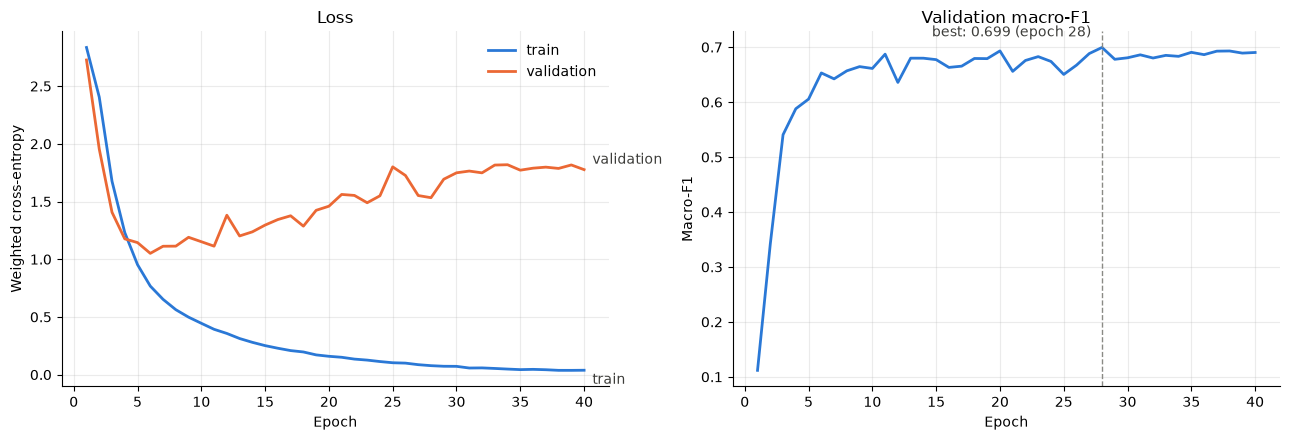

In [31]:
epochs = np.arange(1, num_epochs + 1)
train_color, val_color = "#2a78d6", "#eb6834"

fig, (ax_loss, ax_f1) = plt.subplots(1, 2, figsize=(13, 4.5))

ax_loss.plot(epochs, history["train_loss"], color=train_color, lw=2, label="train")
ax_loss.plot(epochs, history["val_loss"], color=val_color, lw=2, label="validation")
train_on_top = history["train_loss"][-1] >= history["val_loss"][-1]
for key, name, on_top in [
    ("train_loss", "train", train_on_top),
    ("val_loss", "validation", not train_on_top),
]:
    ax_loss.annotate(  # direct label at the end of each line, nudged apart
        name,
        (epochs[-1], history[key][-1]),
        xytext=(6, 7 if on_top else -7),
        textcoords="offset points",
        va="center",
        color="#3d3d3a",
    )
ax_loss.set(xlabel="Epoch", ylabel="Weighted cross-entropy", title="Loss")
ax_loss.legend(frameon=False)

ax_f1.plot(epochs, history["val_f1"], color=train_color, lw=2)
ax_f1.axvline(best_epoch, color="#8a8a85", lw=1, ls="--")
ax_f1.annotate(
    f"best: {best_f1:.3f} (epoch {best_epoch})",
    (best_epoch, best_f1),
    xytext=(-8, 8),
    textcoords="offset points",
    ha="right",
    color="#3d3d3a",
)
ax_f1.set(xlabel="Epoch", ylabel="Macro-F1", title="Validation macro-F1")

for ax in (ax_loss, ax_f1):
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

Load the best model, print the scores for each activity, and draw the confusion matrix.

best epoch 28: validation macro-F1 = 0.6994

              precision    recall  f1-score   support

     walking      0.929     0.880     0.904       374
     jogging      0.997     0.992     0.995       374
      stairs      0.773     0.853     0.811       340
     sitting      0.542     0.309     0.394       375
    standing      0.709     0.782     0.744       340
      typing      0.781     0.725     0.752       374
       teeth      0.852     0.644     0.734       374
        soup      0.555     0.610     0.581       374
       chips      0.379     0.594     0.463       340
       pasta      0.628     0.479     0.543       374
    drinking      0.449     0.497     0.472       374
    sandwich      0.260     0.340     0.294       374
     kicking      0.853     0.866     0.859       374
       catch      0.961     0.794     0.870       374
   dribbling      0.981     0.837     0.903       374
     writing      0.712     0.615     0.660       374
    clapping      0.824     0.778   

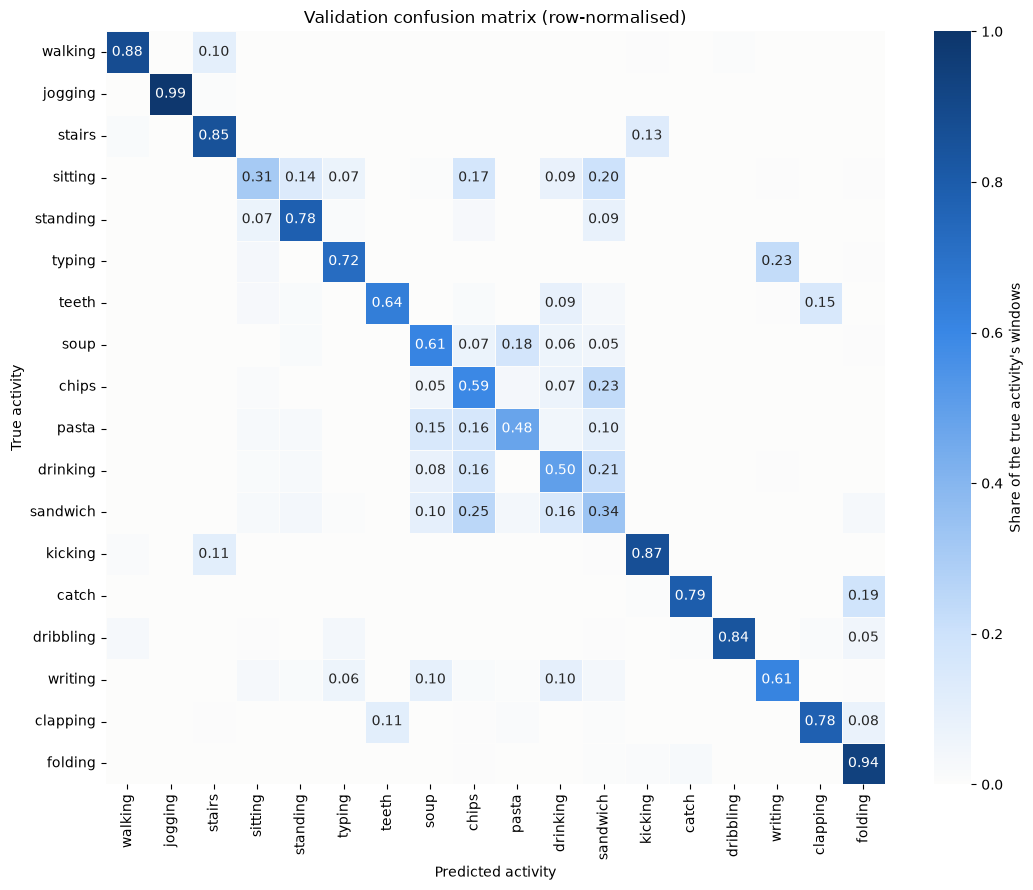

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

model.load_state_dict(best_state)
_, y_true, y_pred = evaluate(model, val_loader)
class_names = [ACTIVITY_MAP[c] for c in classes]

print(
    f"best epoch {best_epoch}: validation macro-F1 = {f1_score(y_true, y_pred, average='macro'):.4f}\n"
)
print(
    classification_report(
        y_true,
        y_pred,
        labels=range(num_classes),
        target_names=class_names,
        digits=3,
        zero_division=0,
    )
)

cm = confusion_matrix(y_true, y_pred, labels=range(num_classes), normalize="true")
labels = np.where(cm >= 0.05, np.char.mod("%.2f", cm), "")  # label only cells >= 5%
blues = LinearSegmentedColormap.from_list(
    "blues", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap=blues,
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="#fcfcfb",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"label": "Share of the true activity's windows"},
    ax=ax,
)
ax.set(
    xlabel="Predicted activity",
    ylabel="True activity",
    title="Validation confusion matrix (row-normalised)",
)
plt.tight_layout()
plt.show()